# Multiclass Logistic Regression from Scratch (One-vs-Rest) — Iris Dataset

The regression model itself (sigmoid, cost function, gradient descent, One-vs-Rest
combination) is written **entirely from scratch using NumPy** — no `sklearn.linear_model`
anywhere.

`scikit-learn` is used **only** as a utility in three places, none of which touch the actual
learning algorithm:
- `LabelEncoder` — to turn the text species column into integer class labels
- `train_test_split` — to split the data
- `StandardScaler` — to standardize features
- `accuracy_score` / `confusion_matrix` — to evaluate predictions after the fact

> **Before running:** download the Iris dataset as `Iris.csv` (e.g. from Kaggle's
> "Iris Species" dataset) and place it in the same folder as this notebook.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_style("whitegrid")
%matplotlib inline


## 1. Load & Explore the Data

In [7]:
df = pd.read_csv("Iris.csv")
df.drop(columns=["Id"], inplace=True)

print(df.shape)
df.head()


(150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df["Species"].value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

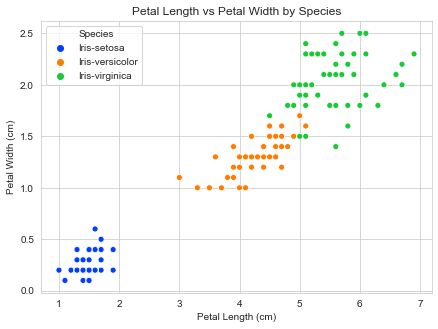

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=df,
    palette="bright"
)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width by Species")
plt.show()


In [10]:
# Encode the species column: this is just a label lookup (setosa -> 0, versicolor -> 1, ...),
# not part of the model — sklearn's LabelEncoder is a convenient, well-tested way to do it.
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])
class_names = label_encoder.classes_
print(dict(zip(class_names, range(len(class_names)))))


{'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


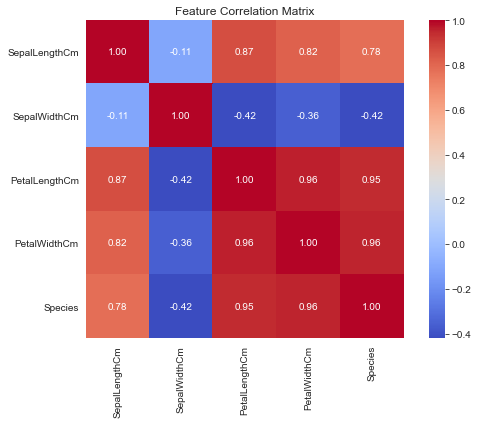

In [11]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


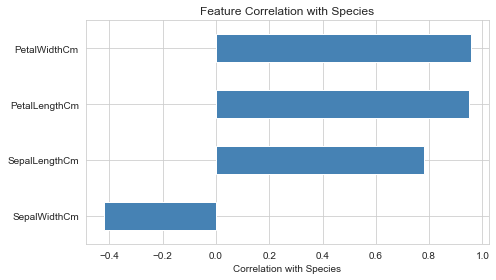

In [12]:
species_corr = corr_matrix["Species"].drop("Species").sort_values(ascending=False)

plt.figure(figsize=(7, 4))
species_corr.plot(kind="barh", color="steelblue")
plt.xlabel("Correlation with Species")
plt.title("Feature Correlation with Species")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 2. Preprocess the Data

- `train_test_split` carves out a held-out test set.
- `StandardScaler` rescales each feature to zero mean / unit variance — fit on the training
  data only, then applied to the test data, to avoid leaking test-set statistics into training.


In [13]:
X = df.drop(columns=["Species"]).values
y = df["Species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2,     stratify=y

)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (120, 4)  X_test: (30, 4)


## 3. Binary Logistic Regression — Written from Scratch

Core pieces, all implemented by hand:

- **Sigmoid:** $\sigma(z) = \dfrac{1}{1 + e^{-z}}$
- **Prediction:** $\hat{y} = \sigma(Xw + b)$
- **Loss (binary cross-entropy):**
  $J(w, b) = -\dfrac{1}{m}\sum_i \left[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$
- **Gradients & update rule (batch gradient descent):**
  $w \leftarrow w - \alpha \cdot \dfrac{1}{m}X^T(\hat{y}-y), \qquad b \leftarrow b - \alpha \cdot \dfrac{1}{m}\sum_i(\hat{y}_i - y_i)$


In [14]:
class BinaryLogisticRegression:
    """Logistic regression for a single binary target, trained with batch gradient descent."""

    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # guard against overflow in exp
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            z = np.dot(X, self.W) + self.b
            y_hat = self.sigmoid(z)

            dW = (1 / n_samples) * np.dot(X.T, (y_hat - y))
            db = (1 / n_samples) * np.sum(y_hat - y)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            eps = 1e-9  # avoid log(0)
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        z = np.dot(X, self.W) + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


## 4. Extend to Multiclass: One-vs-Rest (OvR)

Train one `BinaryLogisticRegression` per class (class *k* = 1, everything else = 0), then, for
each sample, predict the class whose classifier reports the highest probability.


In [15]:
class OneVsRestLogisticRegression:
    """Combines several BinaryLogisticRegression models to handle K classes."""

    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.classifiers = []
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.classifiers = []

        for cls in self.classes:
            print(f"Training classifier for class {cls} ({class_names[cls]}) vs rest")
            y_binary = (y == cls).astype(int)
            clf = BinaryLogisticRegression(
                learning_rate=self.lr,
                n_iterations=self.n_iterations
            )
            clf.fit(X, y_binary)
            self.classifiers.append(clf)

        return self

    def predict_proba(self, X):
        probs = np.zeros((X.shape[0], len(self.classifiers)))
        for idx, clf in enumerate(self.classifiers):
            probs[:, idx] = clf.predict_proba(X)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


In [16]:
model_ovr = OneVsRestLogisticRegression(learning_rate=0.1, n_iterations=9000)
model_ovr.fit(X_train, y_train)


Training classifier for class 0 (Iris-setosa) vs rest
Training classifier for class 1 (Iris-versicolor) vs rest
Training classifier for class 2 (Iris-virginica) vs rest


## 5. Predict & Evaluate

In [17]:
y_pred = model_ovr.predict(X_test)

# sklearn is used here purely to score predictions we already made from scratch
acc = accuracy_score(y_test, y_pred)
print("OvR Test Accuracy:", acc)


OvR Test Accuracy: 1.0


In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


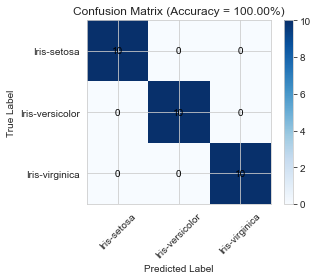

In [19]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


## 6. Loss Curves — Check Each Binary Classifier Converged

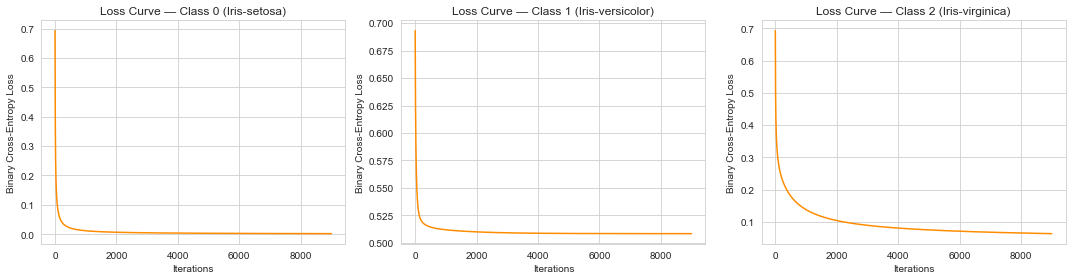

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in enumerate(axes):
    ax.plot(model_ovr.classifiers[idx].loss_history, color="darkorange")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Binary Cross-Entropy Loss")
    ax.set_title(f"Loss Curve — Class {idx} ({class_names[idx]})")
plt.tight_layout()
plt.show()


## Summary

- The **entire logistic regression model** — sigmoid, loss, gradients, gradient descent, and
  the One-vs-Rest combination logic — was written from scratch with NumPy.
- `scikit-learn` was used strictly as a **utility**, for label encoding, the train/test split,
  feature standardization, and post-hoc evaluation (`accuracy_score`, `confusion_matrix`) — it
  never touched the model-fitting step.


In [21]:
# Training accuracy — evaluate the model on the same data it was trained on
y_train_pred = model_ovr.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("OvR Train Accuracy:", train_acc)

y_pred = model_ovr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("OvR Test Accuracy:", acc)

OvR Train Accuracy: 0.95
OvR Test Accuracy: 1.0
